# Ablation studies on whether to compress long-term reflection


Data:
- `ablation_studies_on_reflection_for_crossover_data/<problem>_compression=None/`: do not explicitly compress long-term reflection

Settings:
```
python -u src/oragent/cli.py \
    --algorithm "$ALGORITHM" \
    --problem "$PROBLEM" \
    --max-evolutions 500 \
    --init-pop-size 20 \
    --num-children 2 \
    --max-tree-depth 3 \
    --fast-exploration-for-crossover \
    --max-debug-rounds 2 \
    --max-experiment-repeats 3 \
    --elitist-as-root-period 11 \
    --elitist-enlargement-factor 2.0 \
    --reflection-period 0 \
    --reflection-disabled-for-crossover \
    --reflection-elitist-synchro \
    -- \
    --timeout-seconds 300 \
    --output-dir "$OUTPUT_DIR" \
    > "$OUTPUT_DIR/output.txt" 2>&1
```

- `ablation_studies_on_reflection_for_crossover_data/<problem>_compression=100/`: long-term reflection is instructed to have at most 100 words.

Settings above is revised to add: `reflection-compression=100`: 



In [89]:
# shared plot settings
from plotlib import font_scheme

y_limits = {
    #'tsp_constructive': (6.22, 6.8),
    'tsp_aco': (5.98, 6.12),
    'tsp_pomo': (20.29, 21.5),
    'cvrp_aco': (7.02, 8.5),
    'bpp_offline_aco': (126.4, 131.5),
    'dpp_ga': (12.6, 13.40),
    'mkp_aco': (34.5, 35.90),
    'op_aco': (20, 23.42)
}

color_scheme2 = {
    '100': '#1f77b4',  # blue
    '200': '#ff7f0e',  # orange
    '400': '#2ca02c',  # green
    'None': '#d62728',  # red
}

curve_label = {
    '100': 'Compressed to 100 words',
    '200': 'Compressed to 200 words',
    '400': 'Compressed to 400 words',
    'None': 'Not explicitly compressed',
}

In [90]:
# Load data from output dir
from pathlib import Path
import json

current_dir = Path().resolve()
project_root = current_dir.parent

# TODO: set algorithms and problems to analysis
algorithm = 'or_agent'
problems = ("cvrp_pomo", "dpp_ga", "mkp_aco", "op_aco", "tsp_constructive", "bpp_online")
choices = ("100", "200", "400", "None")  # `true` for `reflection_disabled_for_crossover=True`

# read results.json and store in `results` dict
results = {}
for choice in choices:
    for problem in problems:
        filepath = f"{project_root}/research_results/ablation_studies_on_memory_compression_data/{problem}_compression={choice}/results.json"
        with open(filepath, "r") as fp:
            results[(problem, choice)] = json.load(fp)

for k, v in results.items():
    print(f"=====(problem, choice): {k}=====")
    for entry in v:
        print(entry)

=====(problem, choice): ('cvrp_pomo', '100')=====
{'iteration': 0, 'total_responses': 0, 'total_function_evals': 1, 'total_valid_responses': 0, 'best_obj_overall': 73.3245849609375, 'metrics': {'200': 22.36349868774414, '500': 50.416988372802734, '1000': 147.19326782226562}, 'code_filepath': 'outputs/oragent/cvrp_pomo/standard_mode14_compression_100_rerun/details/lead1_round0_count0_id0_solution.py', 'output_filepath': 'outputs/oragent/cvrp_pomo/standard_mode14_compression_100_rerun/details/lead1_round0_count0_id0_stdout.txt'}
{'iteration': 0, 'total_responses': 35, 'total_function_evals': 35, 'total_valid_responses': 21, 'best_obj_overall': 71.21360905965169, 'metrics': {'200': 22.37929916381836, '500': 51.515281677246094, '1000': 139.74624633789062}, 'code_filepath': 'outputs/oragent/cvrp_pomo/standard_mode14_compression_100_rerun/details/lead1_round0_count2_id2_solution.py', 'output_filepath': 'outputs/oragent/cvrp_pomo/standard_mode14_compression_100_rerun/details/lead1_round0_coun

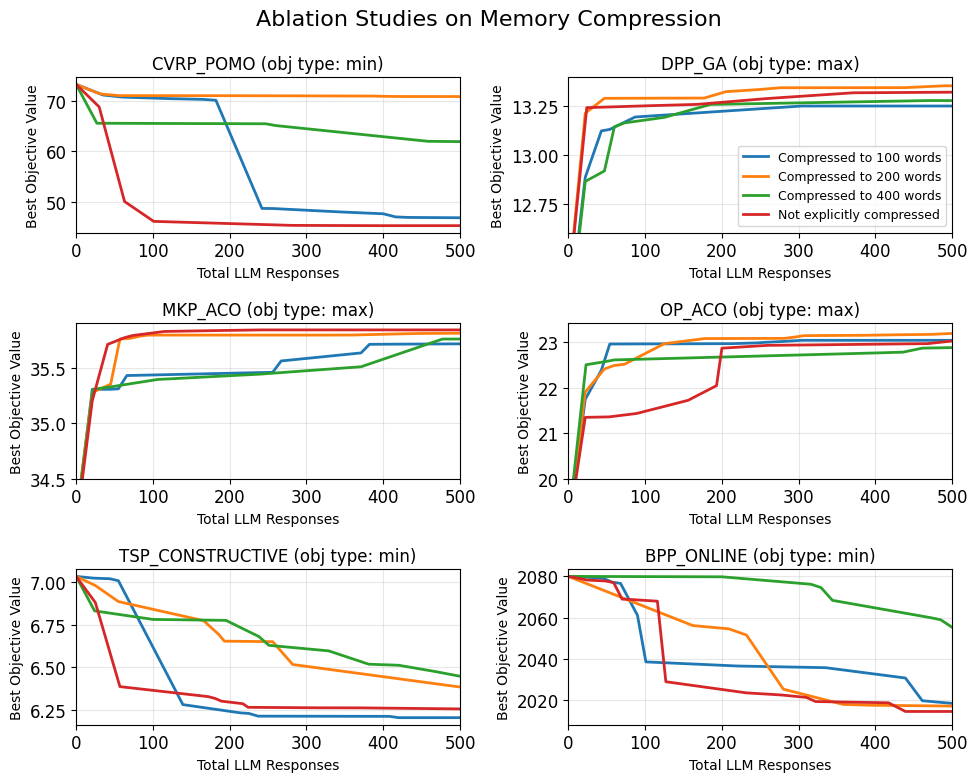

In [91]:
performance_index = 'total_responses'
x_label = 'Total LLM Responses'

# =====x-axis limit based on largest total_responses range=====
# manually set the x-lim
min_x = 0
max_x = 500


# =====Handle data=====
# Add last entry for `results.json`
# the last elitist at x_lim may be missing since results.json is only updated when a new elitist solution is found; we need to manually add the last elitist for plotting
# PS: later we added another logging file - `results_detailed.json` - that record elitist for every iteration (repetitions allowed)
from copy import deepcopy

if True:
    for choice in choices:
        for problem in problems:
            last_entry = deepcopy(results[(problem, choice)][-1])
            if last_entry[performance_index] < max_x:
                last_entry[performance_index] = max_x
                results[(problem, choice)].append(last_entry)


# =====Plot=====
import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

# Create figure with 3 rows, 2 columns (5 subplots total)
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

# Problem titles for each subplot
problem_titles = {
    'cvrp_pomo': 'CVRP_POMO (obj type: min)',
    'dpp_ga': 'DPP_GA (obj type: max)',
    'mkp_aco': 'MKP_ACO (obj type: max)',
    'op_aco': 'OP_ACO (obj type: max)',
    'tsp_constructive': 'TSP_CONSTRUCTIVE (obj type: min)',
    'bpp_online': 'BPP_ONLINE (obj type: min)',
}

# Plot each problem in its own subplot
for idx, problem in enumerate(problems):
    ax = axes[idx]

    # Plot each algorithm
    for choice in choices:
        # Extract total_responses and best_obj_overall
        total_responses = [entry[performance_index] for entry in results[(problem, choice)]]
        best_obj_overall = [entry['best_obj_overall'] for entry in results[(problem, choice)]]

        # Plot the curve
        ax.plot(total_responses, best_obj_overall, markersize=4, label=curve_label[choice], linewidth=2, 
                color=color_scheme2[choice]
                )

    ax.set_xlim(min_x, max_x)
    ax.set_xlabel(x_label, fontsize=10)
    if problem in y_limits:
        ax.set_ylim(y_limits[problem])
    ax.set_ylabel('Best Objective Value', fontsize=10)
    ax.set_title(f'{problem_titles[problem]}', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Add legend only to first subplot
    if idx == 1:
        ax.legend(fontsize=9)

# Hide the empty 6th subplot (index 5)
#axes[5].axis('off')

# Add overall title
fig.suptitle('Ablation Studies on Memory Compression', fontsize=16, y=0.98)

# Adjust layout
plt.tight_layout()
plt.savefig('ablation_memory_compression.png', dpi=300, bbox_inches='tight')
plt.show()

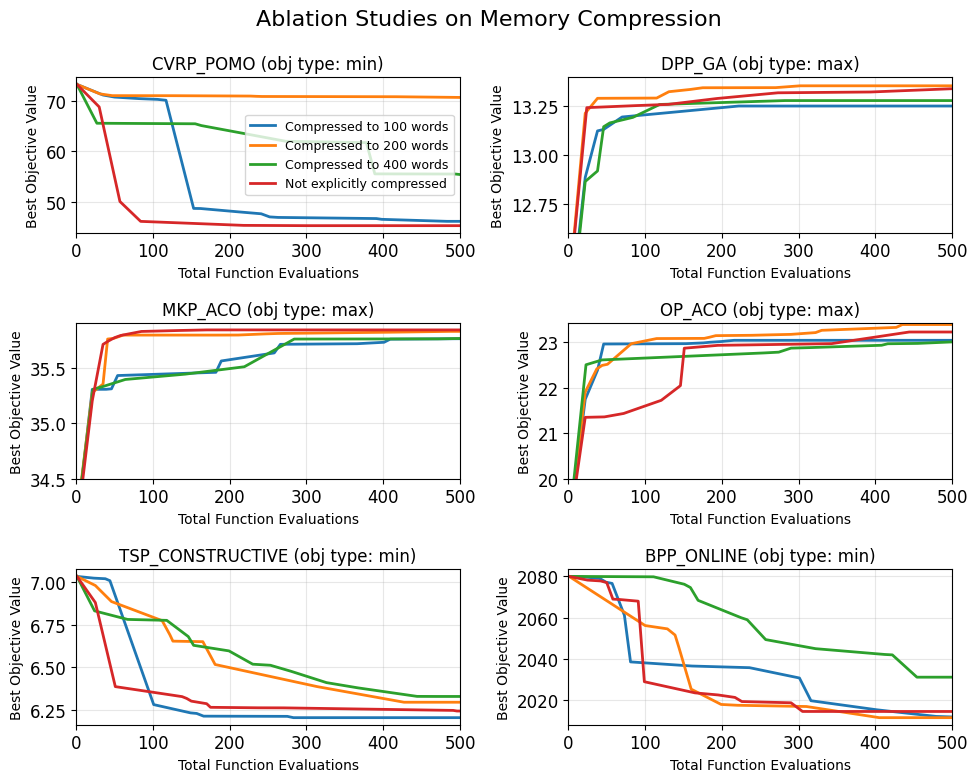

In [92]:
performance_index = 'total_function_evals'
x_label = 'Total Function Evaluations'

# =====x-axis limit based on largest total_responses range=====
# manually set the x-lim
min_x = 0
max_x = 500


# =====Handle data=====
# Add last entry for `results.json`
# the last elitist at x_lim may be missing since results.json is only updated when a new elitist solution is found; we need to manually add the last elitist for plotting
# PS: later we added another logging file - `results_detailed.json` - that record elitist for every iteration (repetitions allowed)
from copy import deepcopy

if True:
    for choice in choices:
        for problem in problems:
            last_entry = deepcopy(results[(problem, choice)][-1])
            if last_entry[performance_index] < max_x:
                last_entry[performance_index] = max_x
                results[(problem, choice)].append(last_entry)


# =====Plot=====
import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

# Create figure with 3 rows, 2 columns (5 subplots total)
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

# Problem titles for each subplot
problem_titles = {
    'cvrp_pomo': 'CVRP_POMO (obj type: min)',
    'dpp_ga': 'DPP_GA (obj type: max)',
    'mkp_aco': 'MKP_ACO (obj type: max)',
    'op_aco': 'OP_ACO (obj type: max)',
    'tsp_constructive': 'TSP_CONSTRUCTIVE (obj type: min)',
    'bpp_online': 'BPP_ONLINE (obj type: min)',
}

# Plot each problem in its own subplot
for idx, problem in enumerate(problems):
    ax = axes[idx]

    # Plot each algorithm
    for choice in choices:
        # Extract total_responses and best_obj_overall
        total_responses = [entry[performance_index] for entry in results[(problem, choice)]]
        best_obj_overall = [entry['best_obj_overall'] for entry in results[(problem, choice)]]

        # Plot the curve
        ax.plot(total_responses, best_obj_overall, markersize=4, label=curve_label[choice], linewidth=2, 
                color=color_scheme2[choice]
                )

    ax.set_xlim(min_x, max_x)
    ax.set_xlabel(x_label, fontsize=10)
    if problem in y_limits:
        ax.set_ylim(y_limits[problem])
    ax.set_ylabel('Best Objective Value', fontsize=10)
    ax.set_title(f'{problem_titles[problem]}', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Add legend only to first subplot
    if idx == 0:
        ax.legend(fontsize=9)

# Hide the empty 6th subplot (index 5)
#axes[5].axis('off')

# Add overall title
fig.suptitle('Ablation Studies on Memory Compression', fontsize=16, y=0.98)

# Adjust layout
plt.tight_layout()
#plt.savefig('ablation_memory_compression.png', dpi=300, bbox_inches='tight')
plt.show()